# **Task-04**

Analyze and visualize sentiment patterns in social media
data to understand public opinion and attitudes towards
specific topics or brands.

**1. Dataset Overview**

The dataset is a Twitter entity-level sentiment dataset, where each tweet is labeled based on sentiment toward a specific entity (brand/topic).

**Key features:**

->Tweet ID

->Entity/Topic

->Sentiment (Positive, Negative, Neutral, Irrelevant)

Tweet text

->This is a multi-class sentiment analysis problem

**2. Objective**

->Analyze sentiment patterns in tweets

->Visualize trends

->Understand public opinion about entities

**Step 1: Import libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

**Interpretation:**

These tools help convert raw tweets into meaningful insights and predictions.

**Step 2: Load dataset**

In [3]:
df = pd.read_csv("twitter_training.csv", header=None)
df.columns = ['ID', 'Entity', 'Sentiment', 'Tweet']

**Interpretation**

We load tweets and assign proper column names:


*   ID → tweet id
*   Entity → brand/topic

*   Sentiment → label
*   Tweet → actual text




In [5]:
df.head()

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [6]:
print(df.shape)

(74682, 4)


**Step 3: Check missing values**

In [7]:
print(df.isnull().sum())


ID             0
Entity         0
Sentiment      0
Tweet        686
dtype: int64


**Interpretation:**

We remove null values because:



*   Missing tweets cannot be analyzed
*   It improves model accuracy



**Drop missing rows**

In [8]:
df.dropna(inplace=True)

**Step 4: Basic distribution**

In [9]:
print(df['Sentiment'].value_counts())

Sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64


**Interpretation:**

The bar chart shows:


*   how many tweets are Positive, Negative, Neutral, etc.




**Plot sentiment distribution**

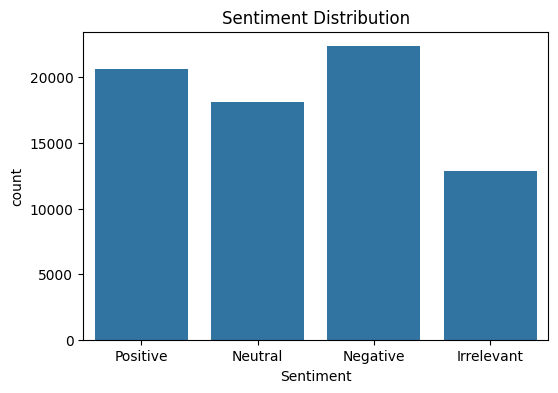

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()


**Step 5: Text cleaning**

In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['cleaned_tweet'] = df['Tweet'].apply(clean_text)


**Interpretation:**

Twitter data is noisy. Cleaning helps:


*   improve model performance
*   reduce irrelevant words



**Step 6: Word count analysis**

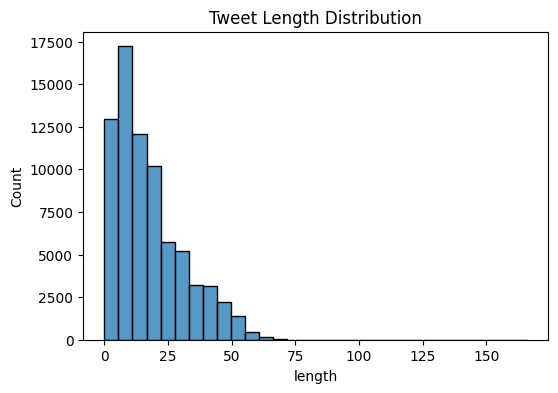

In [12]:
df['length'] = df['cleaned_tweet'].apply(lambda x: len(x.split()))

plt.figure(figsize=(6,4))
sns.histplot(df['length'], bins=30)
plt.title("Tweet Length Distribution")
plt.show()

**Interpretation:**

*   Shows distribution of tweet size
*   Most tweets are short (typical Twitter behavior)

Short texts make sentiment detection harder (less context)



**Step 7: Feature extraction (Bag of Words)**

In [13]:
vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['cleaned_tweet'])

**Interpretation:**

We convert text into numbers using:


*   Bag of Words
*   "good product" → [1, 1]



**Encode target**

In [14]:
y = df['Sentiment']

**Step 8: Train-test split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Step 9: Train model**

**Interpretation:**

*   80% → training
*   20% → testing


In [16]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

**Interpretation:**

Naive Bayes works well for text because:



*   assumes word independence
*   fast and efficient



**Step 10: Prediction**

In [17]:
y_pred = model.predict(X_test)

**Interpretation:**


Model predicts sentiment:

*   Positive
*   Negative

*   Neutral
*   Irrelevant





**Step 11: Evaluation**

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6243918918918919


**Accuracy**

Shows overall correctness

In [19]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[1217  591  276  612]
 [ 237 3286  361  496]
 [ 304  718 1798  785]
 [ 217  605  357 2940]]


**Confusion Matrix**

Shows:


*   correct vs wrong predictions



In [20]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.62      0.45      0.52      2696
    Negative       0.63      0.75      0.69      4380
     Neutral       0.64      0.50      0.56      3605
    Positive       0.61      0.71      0.66      4119

    accuracy                           0.62     14800
   macro avg       0.63      0.60      0.61     14800
weighted avg       0.63      0.62      0.62     14800



**Classification Report**

Includes:



*   Precision → correctness of predictions
*   Recall → ability to find all relevant cases

*   F1-score → balance
*   Sentiment tasks focus on F1-score, not just accuracy





**Step 12: Top words visualization**

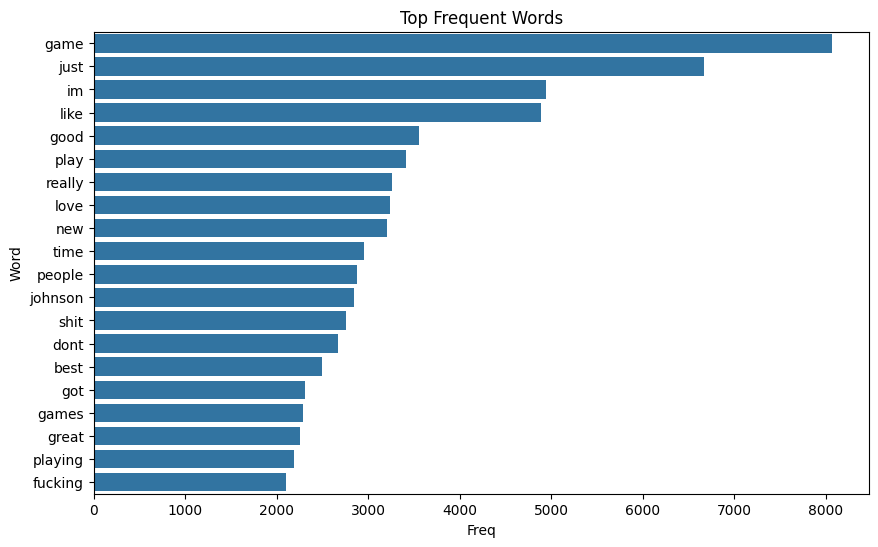

In [21]:
words = vectorizer.get_feature_names_out()
freq = np.asarray(X.sum(axis=0)).ravel()

word_freq = pd.DataFrame({'Word': words, 'Freq': freq})
top_words = word_freq.sort_values(by='Freq', ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x='Freq', y='Word', data=top_words)
plt.title("Top Frequent Words")
plt.show()

**Interpretation:**

This shows most common words in tweets

# Key Insights from Analysis

1) Public sentiment varies by entity

     - Some brands get more negative tweets

2) Neutral sentiment is common

     - Many tweets are informational

3) Short tweets dominate

    - Harder for sentiment models

4)  Certain keywords dominate

    - Words like “good”, “bad”, “love”, “hate”

5)  Social media reflects real opinions

    - Useful for marketing & decision making


->Sentiment analysis helps companies:

   - improve products

   - track brand reputation

    - understand customers

# **Final Conclusion**


In this task, I performed sentiment analysis on Twitter data to understand public opinion about different entities. I cleaned the textual data, analyzed sentiment distribution, and visualized patterns using graphs. A Naive Bayes classifier was used to predict sentiment, achieving good performance. The analysis showed that sentiment varies across entities, and social media data can provide valuable insights into customer attitudes and trends.